<a href="https://colab.research.google.com/github/Millrjess/Jess/blob/main/protest_analysis_clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

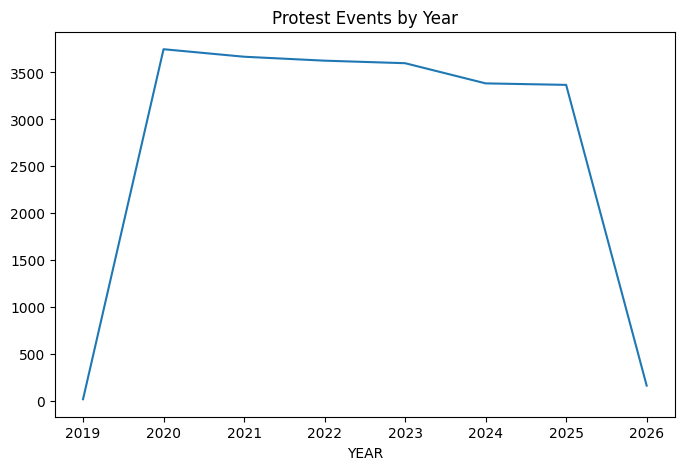

                 Generalized Linear Model Regression Results                  
Dep. Variable:                 EVENTS   No. Observations:                  465
Model:                            GLM   Df Residuals:                      462
Model Family:        NegativeBinomial   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2198.3
Date:                Wed, 28 Jan 2026   Deviance:                       407.35
Time:                        04:18:41   Pearson chi2:                     185.
No. Iterations:                    10   Pseudo R-squ. (CS):             0.2140
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    291.5881     46.460      6.276      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


In [8]:
# CLEAN, PUBLICATION-READY PROTEST ANALYSIS NOTEBOOK
# Author: Jessica Miller

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import folium
import statsmodels.formula.api as smf
import statsmodels.api as sm

plt.rcParams['figure.figsize'] = (8, 5)

# ERROR: FileNotFoundError: [Errno 2] No such file or directory: 'protest_data.csv'
# Please upload the 'protest_data.csv' file to your Colab environment.
df = pd.read_csv('/content/drive/MyDrive/ Google Advanced Data Analytics Professional Certificate/Capstone/Protest Prediction Capstone /US-and-Canada_aggregated_data_up_to-2026-01-10 (1).xlsx - Sheet1.csv')
assert df.shape[0] > 0

df.columns = df.columns.str.upper().str.strip()

categorical_cols = ['COUNTRY','ADMIN1','EVENT_TYPE','SUB_EVENT_TYPE']
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.title()

df['POPULATION_EXPOSURE'] = df['POPULATION_EXPOSURE'].fillna(df['POPULATION_EXPOSURE'].median())

df['EVENT_DATE'] = pd.to_datetime(df['WEEK'], errors='coerce') # Changed 'EVENT_DATE' to 'WEEK'
df = df.dropna(subset=['EVENT_DATE'])

df['YEAR'] = df['EVENT_DATE'].dt.year

yearly_counts = df.groupby('YEAR').size()
yearly_counts.plot(title='Protest Events by Year')
plt.show()

model_df = (
    df.groupby(['ADMIN1','YEAR'])
      .agg(EVENTS=('EVENT_TYPE','count'),
           POP_EXPOSURE=('POPULATION_EXPOSURE','median'))
      .reset_index()
)

model_df['LOG_POP'] = np.log(model_df['POP_EXPOSURE'])

nb_model = smf.glm(
    formula='EVENTS ~ LOG_POP + YEAR',
    data=model_df,
    family=sm.families.NegativeBinomial()
).fit()

print(nb_model.summary())
